# Tech Portfolio Analysis

## 1. Data Loading & Cleaning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import mplfinance as mpf


In [2]:
"""Parse date columns in TechStocks.csv and show result."""

df = pd.read_csv('TechStocks.csv')

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%Y-%m-%d",
    errors="coerce"
                           )

df = df.set_index(["Date", "Ticker"]).sort_index()

df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
df = df[df["Volume"] >= 0]
df = df[df["Open"] >= 0]
df = df[df["High"] >= 0]
df = df[df["Low"] >= 0]
df = df[df["Close"] >= 0]

# Preserve a clean MultiIndex copy so Cell 7 can be rerun safely.
df_base = df.copy()

# Concept: pd.read_csv loads tabular data; pd.to_datetime parses date strings into
# proper datetime objects; set_index with a list of columns builds a sorted MultiIndex;
# dropna and boolean filtering remove invalid rows, leaving a clean DataFrame.

## 2. Feature Engineering.

In [3]:
""" Daily simple returns & log returns. """

df["Simple Return"] = (
    df.groupby("Ticker")["Close"]
    .pct_change()
    .agg(lambda col: col.astype(object)
    .where(col.notna(), None))
)

# Use transform (not apply) so output aligns with df's MultiIndex.
df["Log Return"] = (
    df.groupby("Ticker")["Adj Close"]
    .transform(lambda x: (x / x.shift(1))
    .where(lambda r: r > 0).map(math.log))
    .agg(lambda col: col.astype(object).where(col.notna(), None))
)

""" Rolling 20 day, 50-day, and 200-day moving averages. (on Adj close) """
df["20-day Moving Average"] = (
    df.groupby("Ticker")["Adj Close"]
    .transform(lambda s: s.rolling(window=20).mean())
    .agg(lambda col: col.astype(object).where(col.notna(), None))
)
df["50-day Moving Average"] = (
    df.groupby("Ticker")["Adj Close"]
    .transform(lambda u: u.rolling(window=50).mean())
    .agg(lambda col: col.astype(object).where(col.notna(), None))
)
df["200-day Moving Average"] = (
    df.groupby("Ticker")["Adj Close"]
    .transform(lambda v: v.rolling(window=200).mean())
    .agg(lambda col: col.astype(object).where(col.notna(), None))
)

""" Ann. realized vol — 21-day / 63-day rolling log-return std dev """
df["21-day Volume"] = (
    df.groupby("Ticker")["Log Return"]
    .transform(lambda w: w.rolling(window=21).std() * math.sqrt(252))
    .agg(lambda col: col.astype(object).where(col.notna(), None))
)
df["63-day Volume"] = (
    df.groupby("Ticker")["Log Return"]
    .transform(lambda y: y.rolling(window=63).std() * math.sqrt(252))
    .agg(lambda col: col.astype(object).where(col.notna(), None))
)

# Concept: groupby().transform() applies a per-group function while keeping each
# result aligned to the original index; pct_change() computes simple returns;
# rolling(window=N).mean()/.std() builds moving averages and realized volatility windows.

## 3. Aggregations & Reshaping

In [4]:
""" Monthly average adjusted close price per ticker. """
base_required_cols = {"Close", "Adj Close", "Volume"}
required_index_names = {"Date", "Ticker"}

# If df was overwritten by a wide table, restore from the clean MultiIndex copy.
if (
    "df" not in globals()
    or not base_required_cols.issubset(set(df.columns))
    or not required_index_names.issubset(set(df.index.names))
):
    if "df_base" in globals() and required_index_names.issubset(set(df_base.index.names)):
        df = df_base.copy()
    else:
        raise RuntimeError("No valid source dataframe found. Run Cell 3 first.")

if "Log Return" not in df.columns:
    df["Log Return"] = (
        df.groupby("Ticker")["Close"]
          .transform(lambda x: (x / x.shift(1)).where(lambda r: r > 0).map(math.log))
          .agg(lambda col: col.astype(object).where(col.notna(), None))
    )

df["Monthly Avg Adj Close"] = (
    df.groupby(["Ticker", pd.Grouper(level="Date", freq="ME")])["Adj Close"]
      .transform("mean")
      .agg(lambda col: col.astype(object).where(col.notna(), None))
)

""" Yearly summary statistics per ticker. (mean return, total volume, max drawdown)"""
df["Yearly Mean Return"] = (
    df.groupby(["Ticker", pd.Grouper(level="Date", freq="YE")])["Log Return"]
      .transform("mean")
      .agg(lambda col: col.astype(object).where(col.notna(), None))
)
df["Yearly Total Volume"] = (
    df.groupby(["Ticker", pd.Grouper(level="Date", freq="YE")])["Volume"]
      .transform("sum")
      .agg(lambda col: col.astype(object).where(col.notna(), None))
)

def max_drawdown(series):
    """Calculate the maximum drawdown of a series."""
    cumulative_max = series.cummax()
    drawdown = (series - cumulative_max) / cumulative_max
    return drawdown.min()

df["Yearly Max Drawdown"] = (
    df.groupby(["Ticker", pd.Grouper(level="Date", freq="YE")])["Close"]
      .transform(max_drawdown)
      .agg(lambda col: col.astype(object).where(col.notna(), None))
)

""" Wide-format pivot table of adjusted closes. """
wide_adj_close = (
    df["Adj Close"]
      .unstack("Ticker")
      .sort_index()
      .agg(lambda col: col.astype(object).where(col.notna(), None))
)

""" Correlation matrix of daily log returns. """
wide_log_returns = (
    df["Log Return"]
      .unstack("Ticker")
      .sort_index()
      .agg(lambda col: col.astype(object).where(col.notna(), None))
)
corr_matrix = wide_log_returns.corr()

df = wide_adj_close.copy()

# Concept: pd.Grouper(freq=) enables time-based resampling inside groupby;
# unstack() pivots one level of a MultiIndex into columns to create a wide table;
# corr() computes the pairwise Pearson correlation matrix across all ticker columns.

## 4. Visualizations

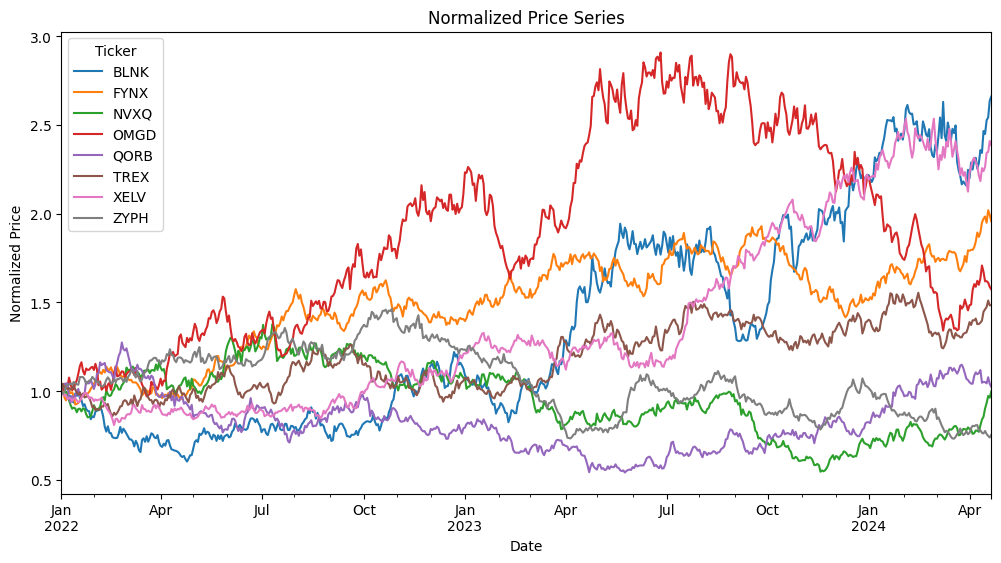

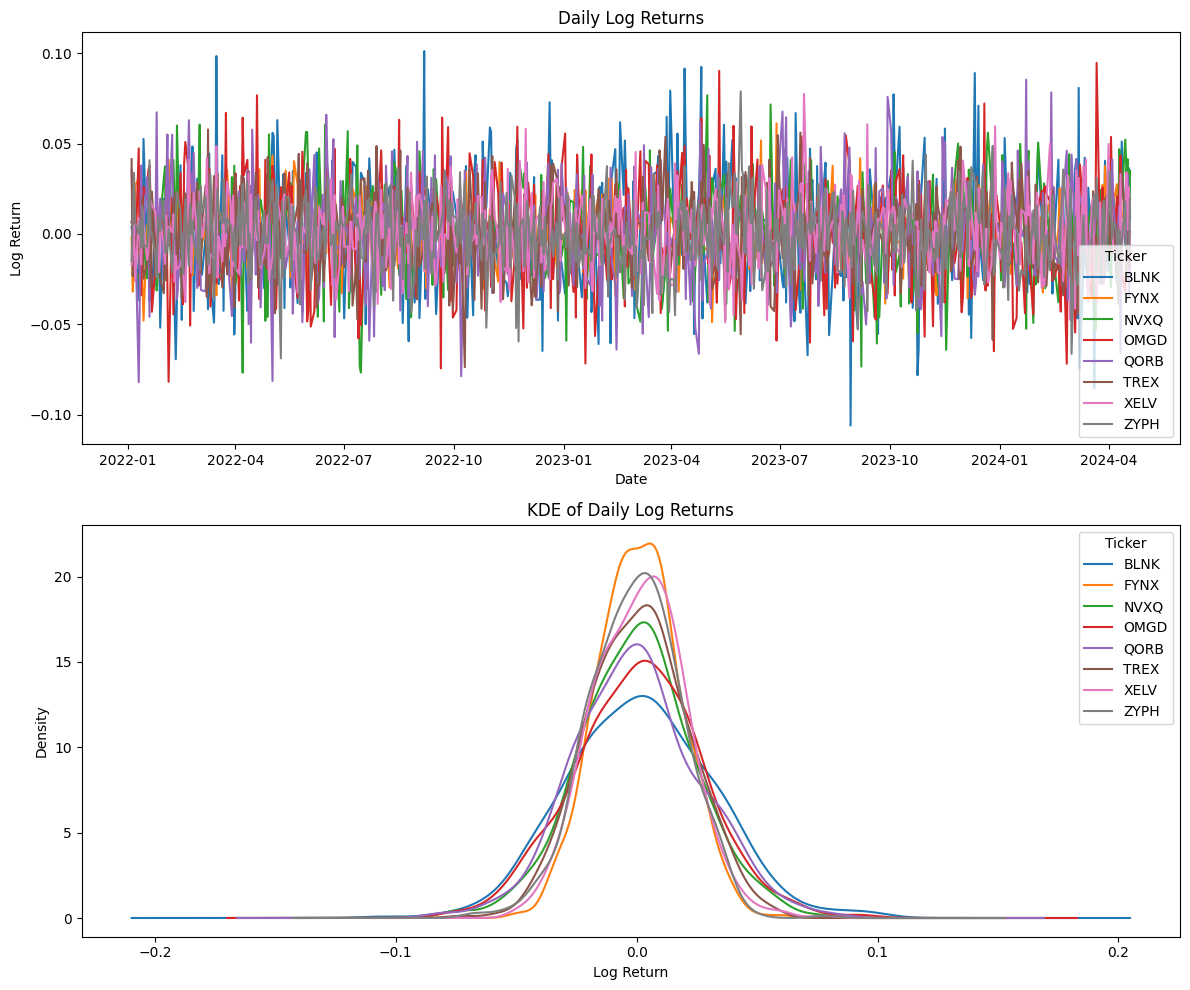

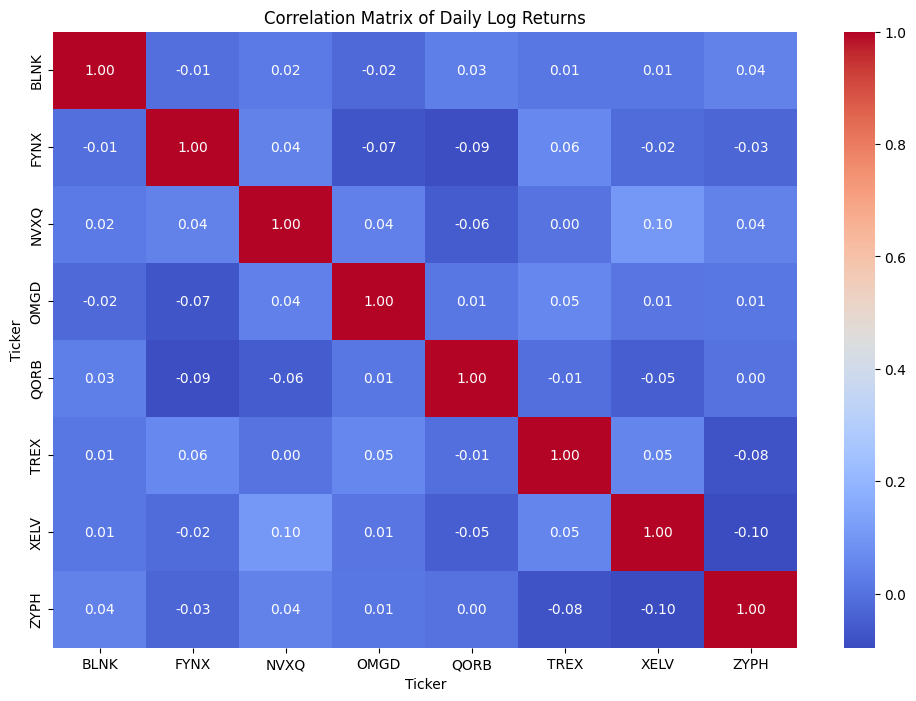

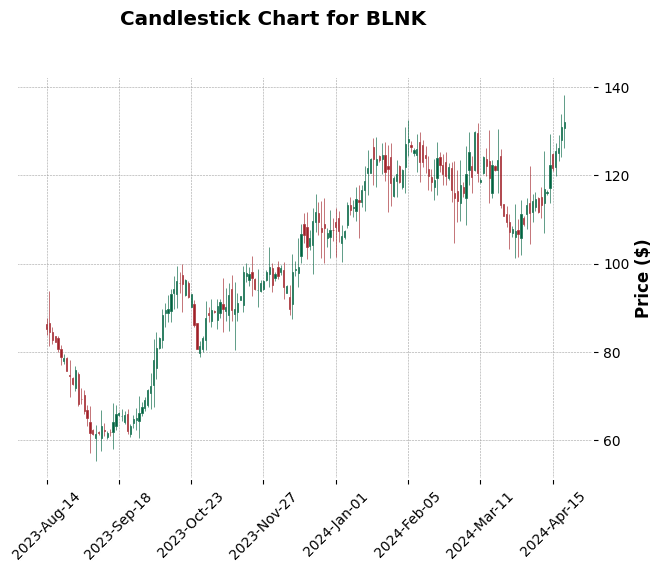

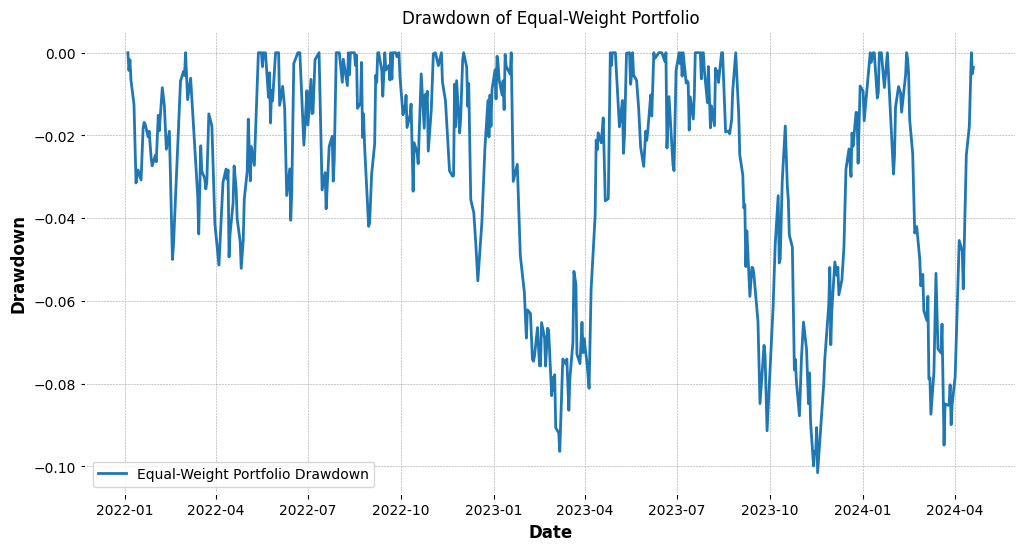

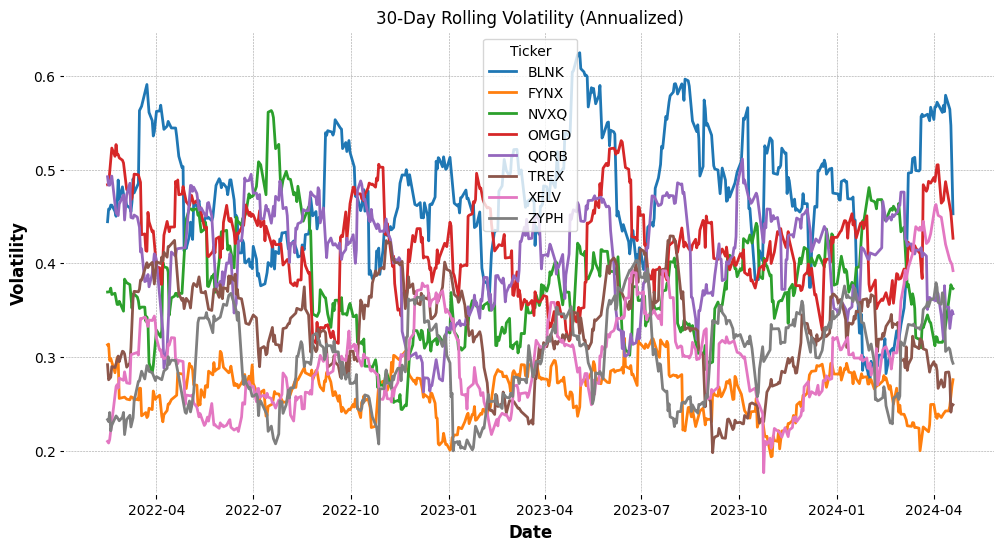

In [5]:
""" Ensure numeric prices before computing returns. """
prices = df.apply(pd.to_numeric, errors="coerce")

""" 1. Multi-line plot: normalized price series """
normalized_prices = prices.div(prices.iloc[0])
normalized_prices.plot(figsize=(12, 6))
plt.title("Normalized Price Series")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend(title="Ticker")
plt.show()

""" 2. Subplots: Daily log returns & KDE per ticker. """
return_ratios = (prices / prices.shift(1)).where(lambda r: r > 0)
log_returns = return_ratios.apply(lambda col: col.map(math.log)).dropna(how="all")
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

for ticker in log_returns.columns:
    ticker_log_returns = log_returns[ticker].dropna()
    if ticker_log_returns.empty:
        continue
    axes[0].plot(ticker_log_returns.index, ticker_log_returns.values, label=ticker)
    ticker_log_returns.plot(kind="kde", ax=axes[1], label=ticker)

axes[0].set_title("Daily Log Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log Return")
axes[0].legend(title="Ticker")
axes[1].set_title("KDE of Daily Log Returns")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Density")
axes[1].legend(title="Ticker")
plt.tight_layout()
plt.show()

""" 3. Heatmap of correlation matrix. """
correlation_matrix = log_returns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Daily Log Returns")
plt.show()

""" 4. Candlestick chart for a selected ticker. """
selected_ticker = "BLNK"  # Change this to any ticker in your dataset.
candlestick_window = 180  # Set to None for full history.
candles_source = df_base if "df_base" in globals() else df
if not isinstance(candles_source.index, pd.MultiIndex) or "Ticker" not in candles_source.index.names:
    raise RuntimeError("Candlestick chart requires MultiIndex source with Date/Ticker. Run Cell 3 first.")

available_tickers = sorted(candles_source.index.get_level_values("Ticker").unique().tolist())
if selected_ticker not in available_tickers:
    raise ValueError(
        f"Ticker '{selected_ticker}' not found. Choose one of: {', '.join(available_tickers)}"
    )

ticker_data = candles_source.xs(selected_ticker, level="Ticker")
ticker_data = ticker_data.dropna(subset=["Open", "High", "Low", "Close"])

if candlestick_window is not None:
    ticker_data = ticker_data.tail(candlestick_window)

ticker_data.index.name = "Date"
ticker_data = ticker_data[["Open", "High", "Low", "Close"]]

mpf.plot(
    ticker_data,
    type="candle",
    style="charles",
    title=f"Candlestick Chart for {selected_ticker}",
    ylabel="Price ($)",
    warn_too_much_data=len(ticker_data) + 1
 )

""" 5. Drawdown plot for the equal-weight portfolio. """
equal_weight_portfolio = log_returns.mean(axis=1).dropna()
cumulative_returns = (1 + equal_weight_portfolio).cumprod()
cumulative_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - cumulative_max) / cumulative_max

plt.figure(figsize=(12, 6))
plt.plot(drawdown.index, drawdown.values, label="Equal-Weight Portfolio Drawdown")
plt.title("Drawdown of Equal-Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

""" 6. Rolling volatility comparison across tickers. """
rolling_window = 30
rolling_volatility = log_returns.rolling(window=rolling_window).std() * math.sqrt(252)
plt.figure(figsize=(12, 6))

for ticker in rolling_volatility.columns:
    ticker_volatility = rolling_volatility[ticker].dropna()
    if ticker_volatility.empty:
        continue

    plt.plot(ticker_volatility.index, ticker_volatility.values, label=ticker)
    
plt.title(f"{rolling_window}-Day Rolling Volatility (Annualized)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend(title="Ticker")
plt.show()

# Concept: DataFrame.div(iloc[0]) normalizes all series to a common baseline;
# plt.subplots() creates multi-panel figures sharing a figure canvas; Series.plot(kind="kde")
# draws kernel density estimates; sns.heatmap() visualizes matrix data with colour intensity;
# mpf.plot() renders OHLC candlestick charts; cummax() tracks the running peak for drawdown.

## 5. Portfolio-level analysis (equal-weight assumption)

Date
2022-01-04    0.007491
2022-01-05   -0.004298
2022-01-06    0.002589
2022-01-07   -0.004896
2022-01-10   -0.005946
                ...   
2024-04-15    0.007192
2024-04-16    0.007593
2024-04-17    0.015441
2024-04-18   -0.005069
2024-04-19    0.001519
Length: 599, dtype: float64


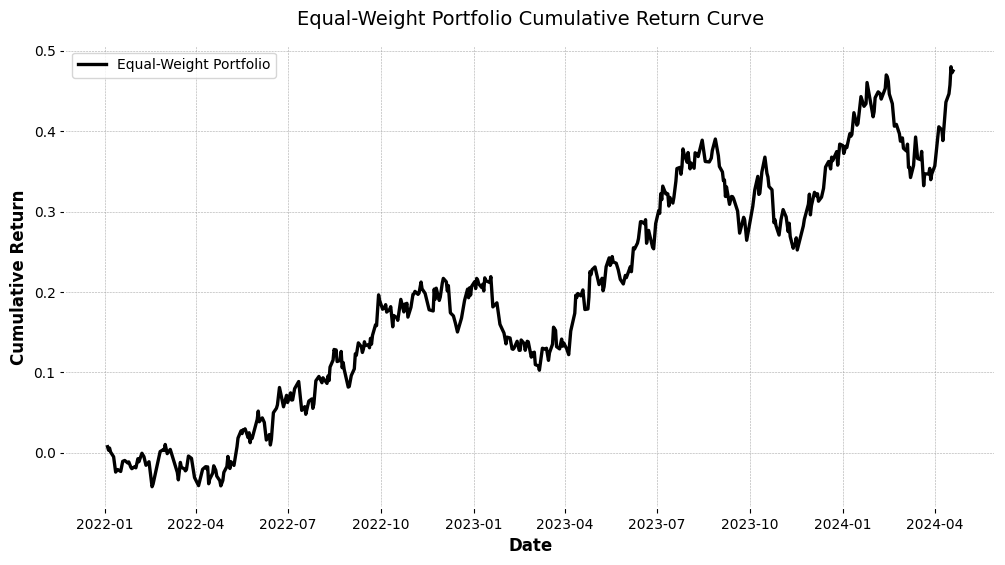

Cumulative return (last value): 0.4750444299119778
Annualized Return: 17.77%
Annualized Volatility: 13.15%
Max Drawdown: -662.49%


In [6]:
""" Daily portfolio log return (equal-weight). """
equal_weight_portfolio = log_returns.mean(axis=1)
portfolio_daily_log_return = equal_weight_portfolio.dropna()
print(portfolio_daily_log_return)

""" Cumulative return curve (equal-weight portfolio). """
portfolio_cumulative_return = portfolio_daily_log_return.cumsum().apply(math.exp) - 1

plt.figure(figsize=(12, 6))
plt.plot(
    portfolio_cumulative_return.index,
    portfolio_cumulative_return.values,
    color="black",
    linewidth=2.4,
    label="Equal-Weight Portfolio",
)
plt.title("Equal-Weight Portfolio Cumulative Return Curve", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.9)
plt.show()

print("Cumulative return (last value):", portfolio_cumulative_return.iloc[-1])

""" Annualized return & volatility (equal-weight portfolio). """
trading_days_per_year = 252
annualized_log_return = portfolio_daily_log_return.mean() * trading_days_per_year
annualized_return = math.exp(annualized_log_return) - 1
annualized_volatility = portfolio_daily_log_return.std() * math.sqrt(trading_days_per_year)

print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")

""" Max drawdown (equal-weight portfolio). """
cumulative_max = portfolio_cumulative_return.cummax()
drawdown = (portfolio_cumulative_return - cumulative_max) / cumulative_max
max_drawdown = drawdown.min()
print(f"Max Drawdown: {max_drawdown:.2%}")

# Concept: mean(axis=1) averages across columns (tickers) to form an equal-weight return;
# cumsum().apply(exp) converts summed log returns into a cumulative return curve;
# std() * sqrt(252) annualizes daily volatility; cummax() tracks the running peak
# so that drawdown can be computed as the percentage decline from each peak.